In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
path = kagglehub.dataset_download("jonathanoheix/face-expression-recognition-dataset")
print("Путь к датасету:", path)

train_path = os.path.join(path, 'images', 'train')
val_path = os.path.join(path, 'images', 'validation')

print(f"Путь для обучения: {train_path}")
print(f"Путь для валидации: {val_path}")

Using Colab cache for faster access to the 'face-expression-recognition-dataset' dataset.
Путь к датасету: /kaggle/input/face-expression-recognition-dataset
Путь для обучения: /kaggle/input/face-expression-recognition-dataset/images/train
Путь для валидации: /kaggle/input/face-expression-recognition-dataset/images/validation


In [ ]:
#загрузчик
class EmotionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

        for i, label in enumerate(self.classes):
            class_path = os.path.join(root_dir, label)
            for img_name in os.listdir(class_path):
                self.images.append(os.path.join(class_path, img_name))
                self.labels.append(i)

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
stats = []
for emotion in os.listdir(train_path):
    path = os.path.join(train_path, emotion)
    if not os.path.isdir(path): continue

    count = len(os.listdir(path))
    stats.append({'Emotion': emotion, 'Count': count})

    # разрешение первой картинки
    img_path = os.path.join(path, os.listdir(path)[0])
    img = Image.open(img_path)
    print(f"Класс {emotion}: {count} фото, размер {img.size}")

Класс surprise: 3205 фото, размер (48, 48)
Класс fear: 4103 фото, размер (48, 48)
Класс angry: 3993 фото, размер (48, 48)
Класс neutral: 4982 фото, размер (48, 48)
Класс sad: 4938 фото, размер (48, 48)
Класс disgust: 436 фото, размер (48, 48)
Класс happy: 7164 фото, размер (48, 48)


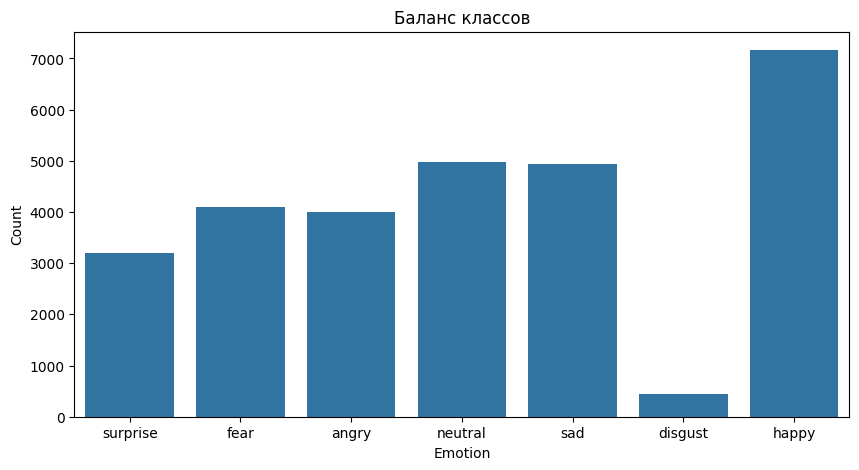

In [ ]:
df = pd.DataFrame(stats)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Emotion', y='Count')
plt.title("Баланс классов")
plt.show()

In [ ]:
#подготовка данных
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
#датасеты (используем класс EmotionDataset)
train_ds = EmotionDataset(train_path, transform=train_transform)
test_ds = EmotionDataset(val_path, transform=test_transform)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [ ]:
# модель resnet18 (для сравнения)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, 7)
model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 212MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#добавим веса классам
class_weights = torch.tensor([1.0, 5.0, 1.0, 0.6, 1.0, 1.0, 1.0]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(weight=class_weights)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Эпоха {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Эпоха 1/10, Loss: 1.4265
Эпоха 2/10, Loss: 1.2219
Эпоха 3/10, Loss: 1.1262
Эпоха 4/10, Loss: 1.0702
Эпоха 5/10, Loss: 1.0210
Эпоха 6/10, Loss: 0.9764
Эпоха 7/10, Loss: 0.9303
Эпоха 8/10, Loss: 0.9008
Эпоха 9/10, Loss: 0.8618
Эпоха 10/10, Loss: 0.8089


In [ ]:
train_ds.classes

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [ ]:
#  модель VGG16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.vgg16(weights='DEFAULT')
# замораживаем свертки
for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096, 7)
model.to(device)

# изменим веса для классов
class_weights = torch.tensor([1.0, 5.0, 1.0, 0.6, 1.0, 1.0, 1.0]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss(weight=class_weights)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Эпоха {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")



Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 84.2MB/s]


Эпоха 1/5, Loss: 1.7348
Эпоха 2/5, Loss: 1.5979
Эпоха 3/5, Loss: 1.5371
Эпоха 4/5, Loss: 1.4873
Эпоха 5/5, Loss: 1.4541


In [ ]:
# квантование
print("\n Сравнение обычной и квантованной модели")
model.to('cpu')
model.eval()

quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear},
    dtype=torch.qint8
)

torch.save(model, "model_fp32.pth")
torch.save(quantized_model, "model_int8.pth")

size_fp32 = os.path.getsize("model_fp32.pth") / (1024 * 1024)
size_int8 = os.path.getsize("model_int8.pth") / (1024 * 1024)

print(f"Размер FP32: {size_fp32:.2f} MB")
print(f"Размер INT8: {size_int8:.2f} MB")
print(f"Коэффициент сжатия: {size_fp32/size_int8:.2f}x")



 Сравнение обычной и квантованной модели


/tmp/ipython-input-3358856254.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Размер FP32: 512.29 MB
Размер INT8: 170.21 MB
Коэффициент сжатия: 3.01x



Метрики
              precision    recall  f1-score   support

       angry       0.40      0.42      0.41       960
     disgust       0.47      0.34      0.40       111
        fear       0.34      0.37      0.35      1018
       happy       0.80      0.72      0.76      1825
     neutral       0.52      0.50      0.51      1216
         sad       0.42      0.35      0.38      1139
    surprise       0.57      0.75      0.65       797

    accuracy                           0.53      7066
   macro avg       0.50      0.50      0.50      7066
weighted avg       0.54      0.53      0.53      7066



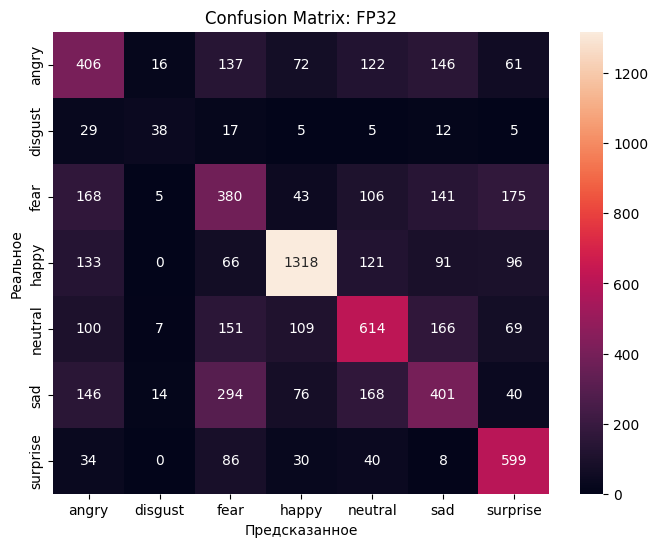

KeyboardInterrupt: 

In [ ]:
#метрики
def get_metrics(model, loader, title):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:

            if next(model.parameters()).is_cuda:
                images = images.to(device)
            else:
                images = images.to('cpu')

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(f"\nМетрики")
    print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

    # матрица ошибок
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_ds.classes, yticklabels=train_ds.classes)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Реальное')
    plt.xlabel('Предсказанное')
    plt.show()

# для обычной модели
get_metrics(model, test_loader, "FP32")

# для квантованной
get_metrics(quantized_model, test_loader, "INT8")

In [ ]:
#создаем временный лоадер с перемешиванием
temp_test_loader = DataLoader(test_ds, batch_size=64, shuffle=True)

all_preds = []
all_labels = []
batch_limit = 10

for i, (images, labels) in enumerate(temp_test_loader):
    if i >= batch_limit:
        break

    outputs = quantized_model(images)
    _, predicted = torch.max(outputs, 1)

    all_preds.extend(predicted.numpy())
    all_labels.extend(labels.numpy())

print("\nметрики для INT8 ")

print(classification_report(all_labels, all_preds, target_names=train_ds.classes, zero_division=0))


метрики для INT8 
              precision    recall  f1-score   support

       angry       0.37      0.42      0.39        93
     disgust       0.25      0.25      0.25         8
        fear       0.31      0.42      0.36        81
       happy       0.81      0.76      0.78       162
     neutral       0.49      0.46      0.48        98
         sad       0.44      0.32      0.37       111
    surprise       0.66      0.72      0.69        87

    accuracy                           0.53       640
   macro avg       0.48      0.48      0.47       640
weighted avg       0.54      0.53      0.53       640



В качестве базовой модели была выбрана нейронка VGG16.Эта модель подходит  для демонстрации эффекта динамического квантования.

Для загрузки и предобработки набора данных был разработан пользовательский класс EmotionDataset. Обработка изображений осуществлялась с использованием библиотеки PIL. В пайплайн были включены операции масштабирования (Resize 224x224), нормализации цветовых каналов и методы аугментации для повышения обобщающей способности модели.

Модель была обучена в течение 5 эпох, достигнув точности Accuracy 0.53.
Была проведена конвертация весов слоев nn.Linear из формата с плавающей точкой (FP32) в целочисленный 8-битный формат (INT8).
В результате объем занимаемой памяти сократился с 512.29 МБ до 170.21 МБ, что соответствует коэффициенту сжатия 3.01x.
итоговая точность составила 0.53, что свидетельствует об отсутствии деградации качества при трехкратном уменьшении веса модели. Так же была использована модель resnet18, которая показала loss 0.8, по сравнению с VGG16 (loss 1.4)